# Tutorial 12 — Explicit FoldForests and Coordinate Control

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/uw-ipd/tmol/blob/master/docs/tutorial/12_explicit_foldforests_and_torsions.ipynb)

This advanced tutorial constructs coupled and per-residue-root FoldForests, changes an inter-chain rigid-body jump, and assigns named backbone torsions in a batched kinematic operation. Every transformation is checked numerically and visualized as both a topology and a three-dimensional structure.

## Learning objectives

By the end, you will be able to:

- encode root-jump, polymer, and ordinary-jump edges explicitly;
- recognize when separate chains are independent or coupled by a jump;
- construct a dandelion forest and understand what it does not idealize;
- extract, modify, and forward-fold rigid-body degrees of freedom;
- set named torsions and confirm the result in a Ramachandran plot.

## Before you begin

Complete [Minimization, Constraints, and Kinematics](05_minimization_constraints_kinematics.ipynb). FoldForest topology decides which atoms move together; it does not add chemical bonds, repair geometry, choose a scoring function, or establish that a conformation is physically favorable.


## Setup

The notebook builds short idealized sequences, so it needs no downloaded structures. The examples are intentionally small enough for CPU documentation execution while using the same public kinematics operations on CUDA.


In [1]:
try:
    import google.colab  # noqa: F401
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    from urllib.request import urlopen

    exec(
        urlopen(
            "https://raw.githubusercontent.com/uw-ipd/tmol/"
            "master/docs/tutorial/colab_setup.py"
        ).read(),
        globals(),
    )
    setup_colab([])


In [2]:
import attrs
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
from IPython.display import display

import tmol
from tmol.kinematics import (
    EdgeType,
    FoldForest,
    JumpDOFTypes,
    NodeType,
    PoseStackKinematicsModule,
    inverseKin,
)

SEED = 20260910
np.random.seed(SEED)
torch.manual_seed(SEED)
device = (
    torch.device("cuda", torch.cuda.current_device())
    if torch.cuda.is_available()
    else torch.device("cpu")
)


def show_table(frame):
    try:
        from itables import show
    except ImportError:
        return display(frame)
    return show(frame)


print(f"TMol {tmol.__version__}; PyTorch {torch.__version__}; device={device}")


TMol 0.1.56; PyTorch 2.13.0+cu132; device=cuda:0


## Compare automatic, coupled, and dandelion topologies

The sequence grammar uses `:` for a chain break. `reasonable_fold_forest()` roots the two chains independently. The custom coupled forest instead attaches chain B to chain A with ordinary jump 0, making six rigid-body degrees of freedom control their relative placement. The dandelion forest independently attaches every block to TMol's virtual root.

Each stored edge is `(edge type, start block, end block, jump index)`. Root jumps always start at `-1`; root-jump and polymer edges use jump index `-1`; ordinary jumps use contiguous indices beginning at zero. Unused padded rows also contain `-1`.


In [3]:
two_chain_pose = tmol.extended_pose_stack_from_sequences(
    "ACDE:FGHI", device=device
)
n_blocks = two_chain_pose.max_n_blocks
chain_b_start = 4

automatic_forest = FoldForest.reasonable_fold_forest(two_chain_pose)

coupled_edges = np.full((1, 4, 4), -1, dtype=np.int64)
coupled_edges[0, 0] = [EdgeType.root_jump, -1, 0, -1]
coupled_edges[0, 1] = [EdgeType.polymer, 0, chain_b_start - 1, -1]
coupled_edges[0, 2] = [EdgeType.jump, 0, chain_b_start, 0]
coupled_edges[0, 3] = [EdgeType.polymer, chain_b_start, n_blocks - 1, -1]
coupled_forest = FoldForest.from_edges(coupled_edges)

dandelion_edges = np.full((1, n_blocks, 4), -1, dtype=np.int64)
dandelion_edges[0, :, 0] = EdgeType.root_jump
dandelion_edges[0, :, 1] = -1
dandelion_edges[0, :, 2] = np.arange(n_blocks)
dandelion_edges[0, :, 3] = -1
dandelion_forest = FoldForest.from_edges(dandelion_edges)


def edge_rows(label, forest):
    rows = []
    for edge_index in range(int(forest.n_edges[0])):
        edge_type, start, end, jump = [
            int(value) for value in forest.edges[0, edge_index]
        ]
        rows.append(
            {
                "forest": label,
                "edge": edge_index,
                "type": EdgeType(edge_type).name,
                "start": start,
                "end": end,
                "jump_index": jump,
            }
        )
    return rows


edge_frame = pd.DataFrame(
    edge_rows("automatic", automatic_forest)
    + edge_rows("coupled", coupled_forest)
    + edge_rows("dandelion", dandelion_forest)
)
show_table(edge_frame)


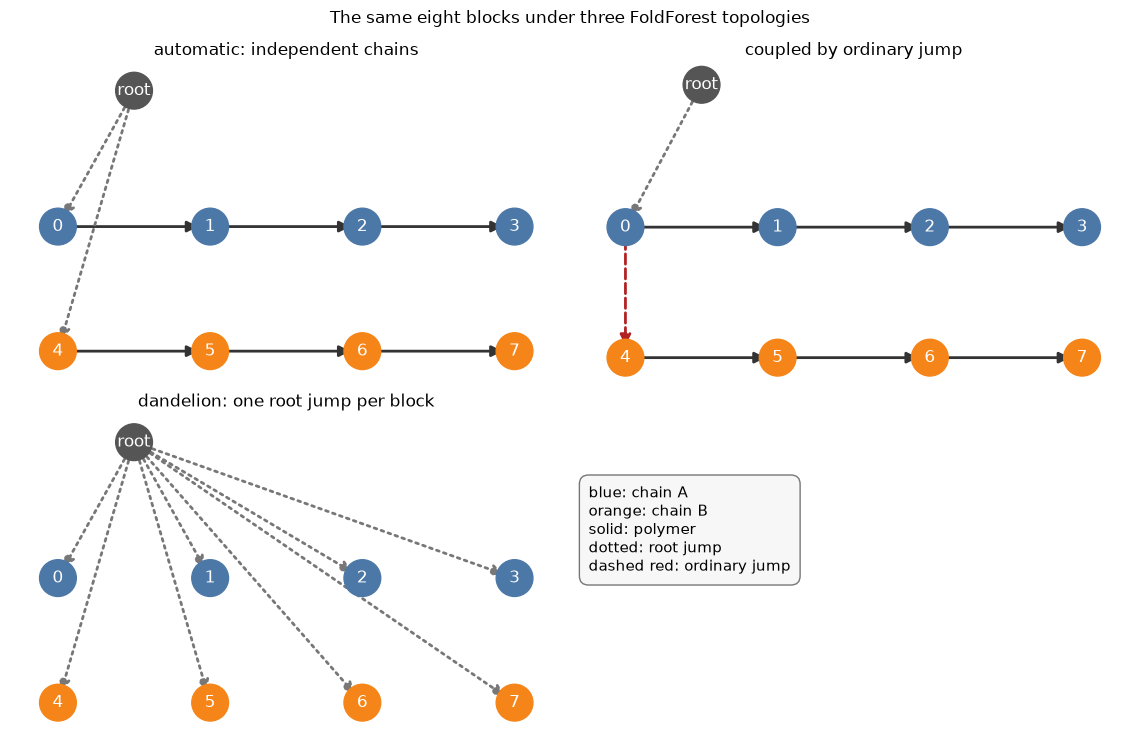

In [4]:
def expanded_graph(forest):
    graph = nx.DiGraph()
    graph.add_node(-1)
    for block in range(n_blocks):
        graph.add_node(block)
    for edge_index in range(int(forest.n_edges[0])):
        edge_type, start, end, _ = [
            int(value) for value in forest.edges[0, edge_index]
        ]
        if edge_type == int(EdgeType.polymer):
            step = 1 if end >= start else -1
            for parent in range(start, end, step):
                graph.add_edge(parent, parent + step, kind="polymer")
        elif edge_type == int(EdgeType.root_jump):
            graph.add_edge(-1, end, kind="root jump")
        else:
            graph.add_edge(start, end, kind="ordinary jump")
    return graph


positions = {-1: (0.5, 1.15)}
positions.update({block: (block % 4, 0.55 - 0.55 * (block // 4)) for block in range(n_blocks)})
forest_map = {
    "automatic: independent chains": automatic_forest,
    "coupled by ordinary jump": coupled_forest,
    "dandelion: one root jump per block": dandelion_forest,
}
fig, axes_grid = plt.subplots(2, 2, figsize=(11.5, 7.5))
axes = axes_grid.flatten()
for axis, (title, forest) in zip(axes[:3], forest_map.items()):
    graph = expanded_graph(forest)
    node_colors = [
        "#555555" if node == -1 else "#4c78a8" if node < chain_b_start else "#f58518"
        for node in graph.nodes
    ]
    nx.draw_networkx_nodes(graph, positions, node_color=node_colors, node_size=700, ax=axis)
    nx.draw_networkx_labels(
        graph,
        positions,
        labels={node: "root" if node == -1 else str(node) for node in graph.nodes},
        font_color="white",
        ax=axis,
    )
    for kind, style, color in [
        ("polymer", "solid", "#333333"),
        ("root jump", "dotted", "#777777"),
        ("ordinary jump", "dashed", "#b22222"),
    ]:
        selected = [(u, v) for u, v, data in graph.edges(data=True) if data["kind"] == kind]
        nx.draw_networkx_edges(
            graph,
            positions,
            edgelist=selected,
            style=style,
            edge_color=color,
            width=2.0,
            arrows=True,
            arrowsize=16,
            ax=axis,
        )
    axis.set_title(title)
    axis.set_axis_off()
axes[3].set_axis_off()
axes[3].text(
    0.02,
    0.78,
    "blue: chain A\norange: chain B\nsolid: polymer\ndotted: root jump\ndashed red: ordinary jump",
    transform=axes[3].transAxes,
    va="top",
    fontsize=11,
    bbox={"boxstyle": "round,pad=0.6", "fc": "#f7f7f7", "ec": "#777777"},
)
fig.suptitle("The same eight blocks under three FoldForest topologies")
plt.tight_layout()
plt.show()


**Expected observations.** The automatic forest has two root jumps, so neither chain's placement depends on the other. The coupled forest has one virtual-root jump plus one red ordinary jump from block 0 to block 4. The dandelion forest has eight root jumps and no polymer traversal. It preserves each block's internal geometry while exposing per-block rigid frames; it does not change chemical connectivity or rebuild the input at ideal bond lengths and angles.


## Perturb the inter-chain rigid-body jump

`PoseStackKinematicsModule` maps kinematic degrees of freedom back to coordinates. `inverseKin()` initializes those degrees of freedom from the current coordinates. We locate the ordinary jump node, translate its downstream chain by 3 Å along the jump frame, and tilt it by 12 degrees.

The correctness test is relational: chain A should remain fixed, while every block in chain B should move. The displacement plot makes that dependency visible and catches accidentally selecting the virtual-root jump instead.


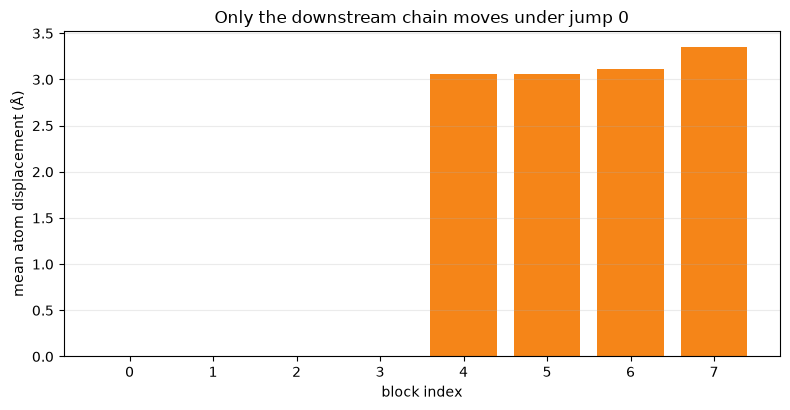

In [5]:
kinematics_module = PoseStackKinematicsModule(two_chain_pose, coupled_forest)
kmd = kinematics_module.kmd
flat_atom_ids = kmd.forest.id[1:].to(torch.int64)
kincoords = torch.zeros(
    (kmd.forest.id.shape[0], 3), dtype=torch.float64, device=device
)
kincoords[1:] = two_chain_pose.coords.reshape(-1, 3)[flat_atom_ids].double()
dofs = inverseKin(kmd.forest, kincoords)

jump_nodes = torch.nonzero(
    kmd.forest.doftype == NodeType.jump, as_tuple=False
).flatten()
inter_chain_jump_node = int(jump_nodes[-1])
moved_dofs = dofs.raw.clone()
moved_dofs[inter_chain_jump_node, JumpDOFTypes.RBx] += 3.0
moved_dofs[inter_chain_jump_node, JumpDOFTypes.RBdel_alpha] += np.deg2rad(12.0)

moved_kincoords = kinematics_module(moved_dofs)
moved_flat = two_chain_pose.coords.reshape(-1, 3).clone()
moved_flat[flat_atom_ids] = moved_kincoords[1:].to(moved_flat.dtype)
jump_moved_pose = attrs.evolve(
    two_chain_pose, coords=moved_flat.view_as(two_chain_pose.coords)
)


def mean_block_displacement(reference, mobile, block):
    start = int(reference.block_coord_offset64[0, block])
    block_type_index = int(reference.block_type_ind64[0, block])
    n_atoms = int(reference.packed_block_types.n_atoms[block_type_index])
    delta = mobile.coords[0, start : start + n_atoms] - reference.coords[0, start : start + n_atoms]
    return float(torch.linalg.vector_norm(delta, dim=-1).mean().detach().cpu())


displacement_frame = pd.DataFrame(
    [
        {
            "block": block,
            "chain": "A" if block < chain_b_start else "B",
            "mean_displacement_A": mean_block_displacement(two_chain_pose, jump_moved_pose, block),
        }
        for block in range(n_blocks)
    ]
)
show_table(displacement_frame)

fig, ax = plt.subplots(figsize=(8, 4.2))
colors = displacement_frame["chain"].map({"A": "#4c78a8", "B": "#f58518"})
ax.bar(displacement_frame["block"], displacement_frame["mean_displacement_A"], color=colors)
ax.set(
    xlabel="block index",
    ylabel="mean atom displacement (Å)",
    title="Only the downstream chain moves under jump 0",
)
ax.set_xticks(range(n_blocks))
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

assert displacement_frame.loc[displacement_frame.chain == "A", "mean_displacement_A"].max() < 1e-3
assert displacement_frame.loc[displacement_frame.chain == "B", "mean_displacement_A"].min() > 1.0


In [6]:
try:
    display(
        tmol.switchable_view(
            {
                "input two-chain pose": two_chain_pose,
                "jump-translated and tilted chain B": jump_moved_pose,
            },
            notes={
                "input two-chain pose": "Chains A and B in their sequence-built placements",
                "jump-translated and tilted chain B": "Chain A is fixed; chain B follows ordinary jump 0",
            },
            width=720,
            height=400,
        )
    )
except ImportError as exc:
    print("Interactive jump comparison unavailable:", exc)


**Expected observations.** Blocks 0–3 remain numerically fixed, while blocks 4–7 move together. In the switcher, the internal geometry of chain B is unchanged because the operation modifies one rigid-body jump. This is coordinate manipulation, not docking: no search or score chose the new placement.


## Assign named torsions in one kinematic pass

`set_named_torsions()` accepts parallel pose, block, name, and value lists. The example sends the five internal alanines of an extended peptide toward an α-helical region (`φ=-60°`, `ψ=-45°`) in one forward-fold. Terminal torsions are deliberately excluded because a named torsion reaching a missing neighboring residue is undefined.

The before/after Ramachandran plot checks the requested internal coordinates directly. Arrows show assignments, not an optimization trajectory.


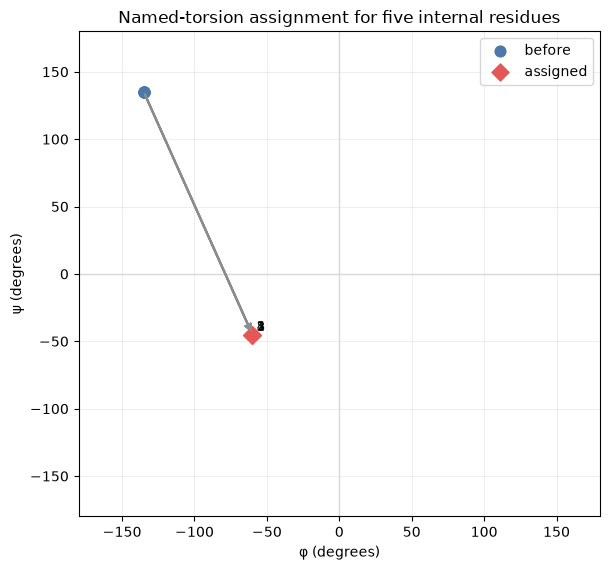

In [7]:
torsion_pose = tmol.extended_pose_stack_from_sequences(
    "AAAAAAA", device=device
)
internal_blocks = list(range(1, 6))
before_torsions = pd.DataFrame(
    [
        {
            "block": block,
            "phi": tmol.get_named_torsions(torsion_pose, 0, block, "phi"),
            "psi": tmol.get_named_torsions(torsion_pose, 0, block, "psi"),
        }
        for block in internal_blocks
    ]
)

request_blocks = [block for block in internal_blocks for _ in ("phi", "psi")]
request_names = [name for _ in internal_blocks for name in ("phi", "psi")]
request_values = [value for _ in internal_blocks for value in (-60.0, -45.0)]
helical_pose = tmol.set_named_torsions(
    torsion_pose,
    poses=[0] * len(request_blocks),
    blocks=request_blocks,
    names=request_names,
    values=request_values,
)
after_torsions = pd.DataFrame(
    [
        {
            "block": block,
            "phi": tmol.get_named_torsions(helical_pose, 0, block, "phi"),
            "psi": tmol.get_named_torsions(helical_pose, 0, block, "psi"),
        }
        for block in internal_blocks
    ]
)
torsion_frame = before_torsions.merge(
    after_torsions, on="block", suffixes=("_before", "_after")
)
show_table(torsion_frame)

fig, ax = plt.subplots(figsize=(6.2, 5.8))
for row in torsion_frame.itertuples():
    ax.annotate(
        "",
        xy=(row.phi_after, row.psi_after),
        xytext=(row.phi_before, row.psi_before),
        arrowprops={"arrowstyle": "->", "color": "0.55", "lw": 1.5},
    )
ax.scatter(torsion_frame.phi_before, torsion_frame.psi_before, label="before", s=60, color="#4c78a8")
ax.scatter(torsion_frame.phi_after, torsion_frame.psi_after, label="assigned", s=75, color="#e45756", marker="D")
for row in torsion_frame.itertuples():
    ax.text(row.phi_after + 3, row.psi_after + 3, str(row.block), fontsize=9)
ax.set(
    xlim=(-180, 180),
    ylim=(-180, 180),
    xlabel="φ (degrees)",
    ylabel="ψ (degrees)",
    title="Named-torsion assignment for five internal residues",
)
ax.axhline(0, color="0.85", lw=1)
ax.axvline(0, color="0.85", lw=1)
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

np.testing.assert_allclose(torsion_frame.phi_after, -60.0, atol=1e-3)
np.testing.assert_allclose(torsion_frame.psi_after, -45.0, atol=1e-3)


In [8]:
try:
    display(
        tmol.switchable_view(
            {
                "extended backbone": torsion_pose,
                "assigned helical φ/ψ": helical_pose,
            },
            notes={
                "extended backbone": "Sequence-built extended torsions",
                "assigned helical φ/ψ": "Internal blocks 1–5 set to φ=-60°, ψ=-45°",
            },
            width=720,
            height=400,
        )
    )
except ImportError as exc:
    print("Interactive torsion comparison unavailable:", exc)


**Expected observations.** All measured internal torsions reach the requested values within numerical tolerance, and the peptide becomes compact and helical-looking. No score was minimized, so clashes or unfavorable side-chain interactions may remain. `set_named_torsions()` preserves the internal lengths and angles carried by the input kinematics; it is not an idealization protocol.

## Choosing a topology

- Use `reasonable_fold_forest()` for ordinary connected chains and gap-aware defaults.
- Use an ordinary jump when one component's placement must be controlled relative to another.
- Use a dandelion forest when a method genuinely operates on independent residue frames.
- Validate edge coverage and jump numbering before minimization or differentiation.
- Treat a FoldForest as a coordinate dependency graph, never as a replacement for chemical connectivity.

## Exercises

1. Reverse the polymer edge for chain A and observe which end remains stationary when changing an internal torsion.
2. Add a second ordinary jump and verify that jump indices are contiguous.
3. Differentiate a coordinate-based objective through the inter-chain jump and inspect the six rigid-body gradients.

## References

- [Tutorial 05 — Minimization, Constraints, and Kinematics](05_minimization_constraints_kinematics.ipynb)
- [Tutorial 06 — FastRelax](06_fast_relax.ipynb)
- [Kinematics API](../api/kinematics.rst)
- [Optimization API](../api/optimization.rst)
